In [1]:
!pip install mysql-connector-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 72.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
regions = pd.read_csv("/content/regions.csv")
disaster_events = pd.read_csv("/content/disaster_events.csv")
impact_assessment = pd.read_csv("/content/impact_assessment.csv")

print("All CSV files loaded successfully!")

All CSV files loaded successfully!


In [4]:
print("REGIONS")
print(regions.shape)
display(regions.head())

print("\nDISASTER EVENTS")
print(disaster_events.shape)
display(disaster_events.head())

print("\nIMPACT ASSESSMENT")
print(impact_assessment.shape)
display(impact_assessment.head())

REGIONS
(1040, 4)


,region_id,region,population,area_sq_km
0,1,Bihar,90048646.0,207448
1,2,Gujarat,NaN,122562
2,3,Odisha,NaN,95079
3,4,Kerala,NaN,206605
4,5,Tamil Nadu,15204415.0,154926



DISASTER EVENTS
(1050, 5)


,event_id,disaster_type,region,event_date,severity
0,1,NaN,West Bengal,NaN,Medium
1,2,Cyclone,Gujarat,2021-07-29,High
2,3,NaN,West Bengal,2021-03-07,Low
3,4,Flood,Gujarat,2021-02-24,High
4,5,Cyclone,Bihar,2022-07-24,Low



IMPACT ASSESSMENT
(1060, 4)


,impact_id,event_id,affected_people,economic_loss_musd
0,1,999,250020.0,989.93
1,2,225,2198805.0,1699.75
2,3,183,1645062.0,NaN
3,4,933,849845.0,4157.40
4,5,389,NaN,NaN


In [5]:
print("REGIONS - Missing Values")
print(regions.isnull().sum())

print("\nDISASTER EVENTS - Missing Values")
print(disaster_events.isnull().sum())

print("\nIMPACT ASSESSMENT - Missing Values")
print(impact_assessment.isnull().sum())

REGIONS - Missing Values
region_id       0
region          0
population    517
area_sq_km      0
dtype: int64

DISASTER EVENTS - Missing Values
event_id           0
disaster_type    185
region             0
event_date        48
severity           0
dtype: int64

IMPACT ASSESSMENT - Missing Values
impact_id               0
event_id                0
affected_people       515
economic_loss_musd    549
dtype: int64


In [6]:
# 1. Fill missing disaster types with "Unknown"
disaster_events["disaster_type"] = disaster_events["disaster_type"].fillna("Unknown")


# 2. Convert event_date safely
# Invalid dates will become NaT instead of causing an error
disaster_events["event_date"] = pd.to_datetime(
    disaster_events["event_date"],
    errors="coerce"
)


# 3. Fill missing population with median
population_median = regions["population"].median()

regions["population"] = regions["population"].fillna(population_median)


# 4. Fill missing affected people with 0
impact_assessment["affected_people"] = (
    impact_assessment["affected_people"].fillna(0)
)


# 5. Fill missing economic losses with 0
impact_assessment["economic_loss_musd"] = (
    impact_assessment["economic_loss_musd"].fillna(0)
)

print("Business rules applied successfully!")

Business rules applied successfully!


In [7]:
print("REGIONS")
print(regions.isnull().sum())

print("\nDISASTER EVENTS")
print(disaster_events.isnull().sum())

print("\nIMPACT ASSESSMENT")
print(impact_assessment.isnull().sum())

REGIONS
region_id     0
region        0
population    0
area_sq_km    0
dtype: int64

DISASTER EVENTS
event_id          0
disaster_type     0
region            0
event_date       48
severity          0
dtype: int64

IMPACT ASSESSMENT
impact_id             0
event_id              0
affected_people       0
economic_loss_musd    0
dtype: int64


In [8]:
print("Regions duplicates:", regions.duplicated().sum())
print("Disaster Events duplicates:", disaster_events.duplicated().sum())
print("Impact Assessment duplicates:", impact_assessment.duplicated().sum())

Regions duplicates: 40
Disaster Events duplicates: 50
Impact Assessment duplicates: 60


In [9]:
regions = regions.drop_duplicates()
disaster_events = disaster_events.drop_duplicates()
impact_assessment = impact_assessment.drop_duplicates()

print("Duplicate records removed successfully!")

Duplicate records removed successfully!


In [10]:
print("Regions shape:", regions.shape)
print("Disaster Events shape:", disaster_events.shape)
print("Impact Assessment shape:", impact_assessment.shape)

Regions shape: (1000, 4)
Disaster Events shape: (1000, 5)
Impact Assessment shape: (1000, 4)


In [11]:
display(regions.head())
display(disaster_events.head())
display(impact_assessment.head())

,region_id,region,population,area_sq_km
0,1,Bihar,90048646.0,207448
1,2,Gujarat,50852776.0,122562
2,3,Odisha,50852776.0,95079
3,4,Kerala,50852776.0,206605
4,5,Tamil Nadu,15204415.0,154926


,event_id,disaster_type,region,event_date,severity
0,1,Unknown,West Bengal,NaT,Medium
1,2,Cyclone,Gujarat,2021-07-29,High
2,3,Unknown,West Bengal,2021-03-07,Low
3,4,Flood,Gujarat,2021-02-24,High
4,5,Cyclone,Bihar,2022-07-24,Low


,impact_id,event_id,affected_people,economic_loss_musd
0,1,999,250020.0,989.93
1,2,225,2198805.0,1699.75
2,3,183,1645062.0,0.00
3,4,933,849845.0,4157.40
4,5,389,0.0,0.00


In [12]:
disaster_impact = pd.merge(
    disaster_events,
    impact_assessment,
    on="event_id",
    how="left"
)

print("Combined dataset shape:", disaster_impact.shape)
display(disaster_impact.head())

Combined dataset shape: (1354, 8)


,event_id,disaster_type,region,event_date,severity,impact_id,affected_people,economic_loss_musd
0,1,Unknown,West Bengal,NaT,Medium,812.0,1238244.0,0.00
1,2,Cyclone,Gujarat,2021-07-29,High,130.0,813610.0,0.00
2,3,Unknown,West Bengal,2021-03-07,Low,NaN,NaN,NaN
3,4,Flood,Gujarat,2021-02-24,High,144.0,0.0,3626.38
4,4,Flood,Gujarat,2021-02-24,High,147.0,2703671.0,3169.25


In [13]:
disaster_impact["affected_people"] = (
    disaster_impact["affected_people"].fillna(0)
)

disaster_impact["economic_loss_musd"] = (
    disaster_impact["economic_loss_musd"].fillna(0)
)

print("Missing impact values handled successfully!")

Missing impact values handled successfully!


In [14]:
print(disaster_impact[
    ["affected_people", "economic_loss_musd"]
].isnull().sum())

affected_people       0
economic_loss_musd    0
dtype: int64


In [15]:
final_data = pd.merge(
    disaster_impact,
    regions,
    on="region",
    how="left"
)

print("Final dataset shape:", final_data.shape)
display(final_data.head())

Final dataset shape: (169547, 11)


,event_id,disaster_type,region,event_date,severity,impact_id,affected_people,economic_loss_musd,region_id,population,area_sq_km
0,1,Unknown,West Bengal,NaT,Medium,812.0,1238244.0,0.0,11,21089818.0,207160
1,1,Unknown,West Bengal,NaT,Medium,812.0,1238244.0,0.0,19,50852776.0,112746
2,1,Unknown,West Bengal,NaT,Medium,812.0,1238244.0,0.0,21,50852776.0,190636
3,1,Unknown,West Bengal,NaT,Medium,812.0,1238244.0,0.0,28,41231955.0,175579
4,1,Unknown,West Bengal,NaT,Medium,812.0,1238244.0,0.0,38,52122567.0,181218


In [16]:
region_counts = regions["region"].value_counts()

print(region_counts[region_counts > 1])

region
UP             146
West Bengal    131
Assam          129
Odisha         126
Gujarat        120
Kerala         118
Bihar          116
Tamil Nadu     114
Name: count, dtype: int64


In [17]:
print("Total region records:", len(regions))
print("Unique region names:", regions["region"].nunique())

Total region records: 1000
Unique region names: 8


In [18]:
print(regions["region"].value_counts())

region
UP             146
West Bengal    131
Assam          129
Odisha         126
Gujarat        120
Kerala         118
Bihar          116
Tamil Nadu     114
Name: count, dtype: int64


In [19]:
region_summary = regions.groupby("region").agg(
    unique_region_ids=("region_id", "nunique"),
    unique_populations=("population", "nunique"),
    unique_areas=("area_sq_km", "nunique")
)

display(region_summary)

,unique_region_ids,unique_populations,unique_areas
region,,,
Assam,129,64,129
Bihar,116,65,116
Gujarat,120,67,120
Kerala,118,54,118
Odisha,126,57,126
Tamil Nadu,114,62,114
UP,146,72,146
West Bengal,131,69,131


In [20]:
clean_regions = (
    regions.groupby("region", as_index=False)
    .agg(
        population=("population", "median"),
        area_sq_km=("area_sq_km", "median")
    )
)

clean_regions

,region,population,area_sq_km
0,Assam,50852776.0,144407.0
1,Bihar,50852776.0,135443.5
2,Gujarat,50852776.0,139758.5
3,Kerala,50852776.0,133442.5
4,Odisha,50852776.0,139113.0
5,Tamil Nadu,50852776.0,157411.0
6,UP,50852776.0,145309.5
7,West Bengal,50852776.0,145450.0


In [21]:
print("Clean regions:", len(clean_regions))
print(clean_regions)

Clean regions: 8
        region  population  area_sq_km
0        Assam  50852776.0    144407.0
1        Bihar  50852776.0    135443.5
2      Gujarat  50852776.0    139758.5
3       Kerala  50852776.0    133442.5
4       Odisha  50852776.0    139113.0
5   Tamil Nadu  50852776.0    157411.0
6           UP  50852776.0    145309.5
7  West Bengal  50852776.0    145450.0


In [22]:
final_data = pd.merge(
    disaster_impact,
    clean_regions,
    on="region",
    how="left"
)

print("Final dataset shape:", final_data.shape)
display(final_data.head())

Final dataset shape: (1354, 10)


,event_id,disaster_type,region,event_date,severity,impact_id,affected_people,economic_loss_musd,population,area_sq_km
0,1,Unknown,West Bengal,NaT,Medium,812.0,1238244.0,0.00,50852776.0,145450.0
1,2,Cyclone,Gujarat,2021-07-29,High,130.0,813610.0,0.00,50852776.0,139758.5
2,3,Unknown,West Bengal,2021-03-07,Low,NaN,0.0,0.00,50852776.0,145450.0
3,4,Flood,Gujarat,2021-02-24,High,144.0,0.0,3626.38,50852776.0,139758.5
4,4,Flood,Gujarat,2021-02-24,High,147.0,2703671.0,3169.25,50852776.0,139758.5


In [23]:
print("Rows in disaster_impact:", len(disaster_impact))
print("Rows in final_data:", len(final_data))

print("\nMissing region information:")
print(final_data[["population", "area_sq_km"]].isnull().sum())

Rows in disaster_impact: 1354
Rows in final_data: 1354

Missing region information:
population    0
area_sq_km    0
dtype: int64


In [24]:
print("Missing values in final dataset:")
print(final_data.isnull().sum())

Missing values in final dataset:
event_id                0
disaster_type           0
region                  0
event_date             66
severity                0
impact_id             354
affected_people         0
economic_loss_musd      0
population              0
area_sq_km              0
dtype: int64


In [25]:
print("\nFinal dataset information:")
print(final_data.info())


Final dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1354 entries, 0 to 1353
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   event_id            1354 non-null   int64         
 1   disaster_type       1354 non-null   object        
 2   region              1354 non-null   object        
 3   event_date          1288 non-null   datetime64[ns]
 4   severity            1354 non-null   object        
 5   impact_id           1000 non-null   float64       
 6   affected_people     1354 non-null   float64       
 7   economic_loss_musd  1354 non-null   float64       
 8   population          1354 non-null   float64       
 9   area_sq_km          1354 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(3)
memory usage: 105.9+ KB
None


In [26]:
!which mysql

In [27]:
!mysql --version

/bin/bash: line 1: mysql: command not found


In [28]:
!apt-get update -qq
!apt-get install -y mysql-server

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libaio1 libcgi-fast-perl libcgi-pm-perl libclone-perl libencode-locale-perl
  libfcgi-bin libfcgi-perl libfcgi0ldbl libhtml-parser-perl
  libhtml-tagset-perl libhtml-template-perl libhttp-date-perl
  libhttp-message-perl libio-html-perl liblwp-mediatypes-perl libmecab2
  libprotobuf-lite23 liburi-perl mecab-ipadic mecab-ipadic-utf8 mecab-utils
  mysql-client-8.0 mysql-client-core-8.0 mysql-server-8.0
  mysql-server-core-8.0
Suggested packages:
  libdata-dump-perl libipc-sharedcache-perl libbusiness-isbn-perl libwww-perl
  mailx tinyca
The following NEW packages will be installed:
  libaio1 libcgi-fast-perl libcgi-pm-perl libclone-perl libencode-locale

In [29]:
!service mysql start

 * Starting MySQL database server mysqld
su: warning: cannot change directory to /nonexistent: No such file or directory
   ...done.


In [30]:
!mysql --version

mysql  Ver 8.0.46-0ubuntu0.22.04.3 for Linux on x86_64 ((Ubuntu))


In [31]:
!mysql -u root -e "CREATE DATABASE IF NOT EXISTS disaster_db;"

In [32]:
!mysql -u root -e "SHOW DATABASES;"

+--------------------+
| Database           |
+--------------------+
| disaster_db        |
| information_schema |
| mysql              |
| performance_schema |
| sys                |
+--------------------+


In [33]:
import subprocess

sql = """
CREATE TABLE IF NOT EXISTS regions (
    region_id INT AUTO_INCREMENT PRIMARY KEY,
    region VARCHAR(100) NOT NULL UNIQUE,
    population BIGINT,
    area_sq_km DECIMAL(12,2)
);
"""

subprocess.run(
    ["mysql", "-u", "root", "disaster_db", "-e", sql],
    check=True
)

print("regions table created successfully!")

regions table created successfully!


In [34]:
import subprocess

result = subprocess.run(
    ["mysql", "-u", "root", "disaster_db", "-e", "DESCRIBE regions;"],
    capture_output=True,
    text=True,
    check=True
)

print(result.stdout)

Field	Type	Null	Key	Default	Extra
region_id	int	NO	PRI	NULL	auto_increment
region	varchar(100)	NO	UNI	NULL	
population	bigint	YES		NULL	
area_sq_km	decimal(12,2)	YES		NULL	



In [35]:
sql = """
CREATE TABLE IF NOT EXISTS disaster_events (
    event_id INT PRIMARY KEY,
    disaster_type VARCHAR(50) NOT NULL,
    region VARCHAR(100) NOT NULL,
    event_date DATE,
    severity VARCHAR(20) NOT NULL
);
"""

subprocess.run(
    ["mysql", "-u", "root", "disaster_db", "-e", sql],
    check=True
)

print("disaster_events table created successfully!")

disaster_events table created successfully!


In [36]:
sql = """
CREATE TABLE IF NOT EXISTS impact_assessment (
    impact_id INT AUTO_INCREMENT PRIMARY KEY,
    event_id INT NOT NULL,
    affected_people BIGINT NOT NULL DEFAULT 0,
    economic_loss_musd DECIMAL(15,2) NOT NULL DEFAULT 0,
    FOREIGN KEY (event_id) REFERENCES disaster_events(event_id)
);
"""

subprocess.run(
    ["mysql", "-u", "root", "disaster_db", "-e", sql],
    check=True
)

print("impact_assessment table created successfully!")

impact_assessment table created successfully!


In [38]:
!mysql -u root -e "CREATE USER IF NOT EXISTS 'disaster_user'@'localhost' IDENTIFIED BY 'disaster123';"

In [39]:
!mysql -u root -e "GRANT ALL PRIVILEGES ON disaster_db.* TO 'disaster_user'@'localhost';"

In [40]:
!mysql -u root -e "FLUSH PRIVILEGES;"

In [41]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="disaster_user",
    password="disaster123",
    database="disaster_db"
)

print("Connected to disaster_db successfully!")

cursor = conn.cursor()
cursor.execute("SELECT DATABASE()")

print("Current database:", cursor.fetchone()[0])

cursor.close()
conn.close()

Connected to disaster_db successfully!
Current database: disaster_db


In [42]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="disaster_user",
    password="disaster123",
    database="disaster_db"
)

cursor = conn.cursor()

insert_query = """
INSERT INTO regions (region, population, area_sq_km)
VALUES (%s, %s, %s)
"""

region_data = [
    tuple(row)
    for row in clean_regions[
        ["region", "population", "area_sq_km"]
    ].itertuples(index=False, name=None)
]

cursor.executemany(insert_query, region_data)
conn.commit()

print(cursor.rowcount, "region records inserted successfully!")

cursor.close()
conn.close()

8 region records inserted successfully!


In [43]:
!mysql -u disaster_user -pdisaster123 disaster_db -e "SELECT * FROM regions;"

mysql: [Warning] Using a password on the command line interface can be insecure.
+-----------+-------------+------------+------------+
| region_id | region      | population | area_sq_km |
+-----------+-------------+------------+------------+
|         1 | Assam       |   50852776 |  144407.00 |
|         2 | Bihar       |   50852776 |  135443.50 |
|         3 | Gujarat     |   50852776 |  139758.50 |
|         4 | Kerala      |   50852776 |  133442.50 |
|         5 | Odisha      |   50852776 |  139113.00 |
|         6 | Tamil Nadu  |   50852776 |  157411.00 |
|         7 | UP          |   50852776 |  145309.50 |
|         8 | West Bengal |   50852776 |  145450.00 |
+-----------+-------------+------------+------------+


In [44]:
conn = mysql.connector.connect(
    host="localhost",
    user="disaster_user",
    password="disaster123",
    database="disaster_db"
)

cursor = conn.cursor()

insert_query = """
INSERT INTO disaster_events
(event_id, disaster_type, region, event_date, severity)
VALUES (%s, %s, %s, %s, %s)
"""

event_data = []

for row in disaster_events.itertuples(index=False, name=None):
    event_id, disaster_type, region, event_date, severity = row

    # Convert pandas NaT to None for MySQL
    if pd.isna(event_date):
        event_date = None

    event_data.append(
        (event_id, disaster_type, region, event_date, severity)
    )

cursor.executemany(insert_query, event_data)
conn.commit()

print(cursor.rowcount, "disaster event records inserted successfully!")

cursor.close()
conn.close()

1000 disaster event records inserted successfully!


In [45]:
conn = mysql.connector.connect(
    host="localhost",
    user="disaster_user",
    password="disaster123",
    database="disaster_db"
)

cursor = conn.cursor()

insert_query = """
INSERT INTO impact_assessment
(event_id, affected_people, economic_loss_musd)
VALUES (%s, %s, %s)
"""

impact_data = []

for row in impact_assessment.itertuples(index=False, name=None):
    impact_id, event_id, affected_people, economic_loss = row

    if pd.isna(affected_people):
        affected_people = 0

    if pd.isna(economic_loss):
        economic_loss = 0

    impact_data.append(
        (event_id, affected_people, economic_loss)
    )

cursor.executemany(insert_query, impact_data)
conn.commit()

print(cursor.rowcount, "impact assessment records inserted successfully!")

cursor.close()
conn.close()

1000 impact assessment records inserted successfully!


In [47]:
conn = mysql.connector.connect(
    host="localhost",
    user="disaster_user",
    password="disaster123",
    database="disaster_db"
)

cursor = conn.cursor()

cursor.execute("SELECT COUNT(*) FROM regions")
print("Regions:", cursor.fetchone()[0])

cursor.execute("SELECT COUNT(*) FROM disaster_events")
print("Disaster Events:", cursor.fetchone()[0])

cursor.execute("SELECT COUNT(*) FROM impact_assessment")
print("Impact Assessment:", cursor.fetchone()[0])

cursor.close()
conn.close()

Regions: 8
Disaster Events: 1000
Impact Assessment: 1000


In [48]:
conn = mysql.connector.connect(
    host="localhost",
    user="disaster_user",
    password="disaster123",
    database="disaster_db"
)

cursor = conn.cursor()

query = """
SELECT
    de.region,
    SUM(ia.affected_people) AS total_affected_people
FROM disaster_events de
JOIN impact_assessment ia
    ON de.event_id = ia.event_id
GROUP BY de.region
ORDER BY total_affected_people DESC
LIMIT 5;
"""

cursor.execute(query)

for row in cursor.fetchall():
    print(row)

cursor.close()
conn.close()

('West Bengal', Decimal('171433034'))
('UP', Decimal('167685642'))
('Tamil Nadu', Decimal('167556762'))
('Bihar', Decimal('165850182'))
('Gujarat', Decimal('158766452'))


In [49]:
conn = mysql.connector.connect(
    host="localhost",
    user="disaster_user",
    password="disaster123",
    database="disaster_db"
)

query = """
SELECT
    de.region,
    SUM(ia.affected_people) AS total_affected_people
FROM disaster_events de
JOIN impact_assessment ia
    ON de.event_id = ia.event_id
GROUP BY de.region
ORDER BY total_affected_people DESC
LIMIT 5;
"""

top5_regions = pd.read_sql(query, conn)

conn.close()

display(top5_regions)

/tmp/ipykernel_504/3399335837.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  top5_regions = pd.read_sql(query, conn)


,region,total_affected_people
0,West Bengal,171433034.0
1,UP,167685642.0
2,Tamil Nadu,167556762.0
3,Bihar,165850182.0
4,Gujarat,158766452.0


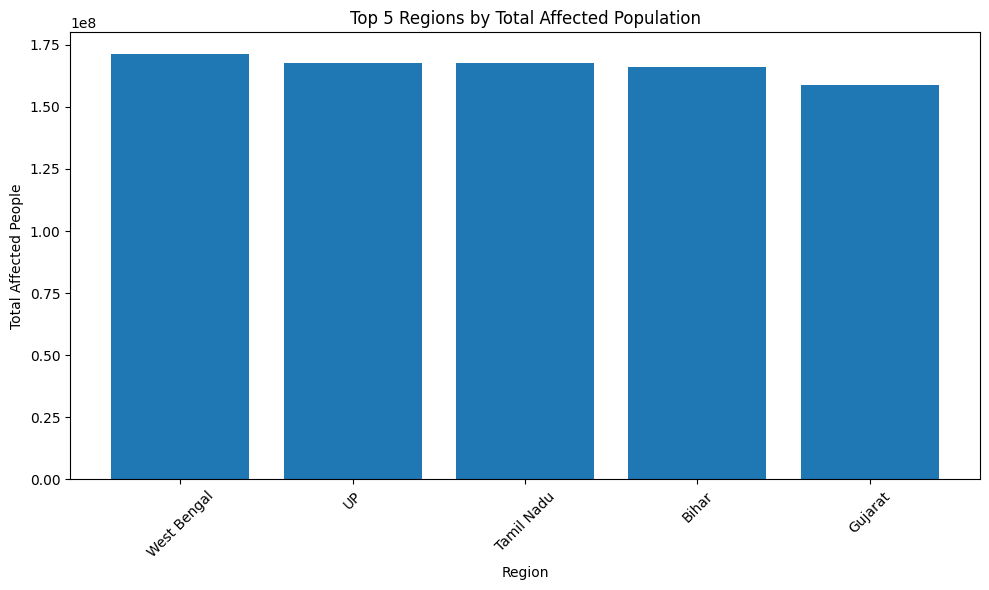

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    top5_regions["region"],
    top5_regions["total_affected_people"]
)

plt.title("Top 5 Regions by Total Affected Population")
plt.xlabel("Region")
plt.ylabel("Total Affected People")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [51]:
conn = mysql.connector.connect(
    host="localhost",
    user="disaster_user",
    password="disaster123",
    database="disaster_db"
)

query = """
SELECT
    disaster_type,
    severity,
    COUNT(*) AS disaster_count
FROM disaster_events
GROUP BY disaster_type, severity
ORDER BY disaster_type, severity;
"""

severity_data = pd.read_sql(query, conn)

conn.close()

display(severity_data)

/tmp/ipykernel_504/2079372791.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  severity_data = pd.read_sql(query, conn)


,disaster_type,severity,disaster_count
0,Cyclone,High,45
1,Cyclone,Low,60
2,Cyclone,Medium,61
3,Drought,High,65
4,Drought,Low,60
5,Drought,Medium,48
6,Earthquake,High,67
7,Earthquake,Low,41
8,Earthquake,Medium,48
9,Flood,High,62


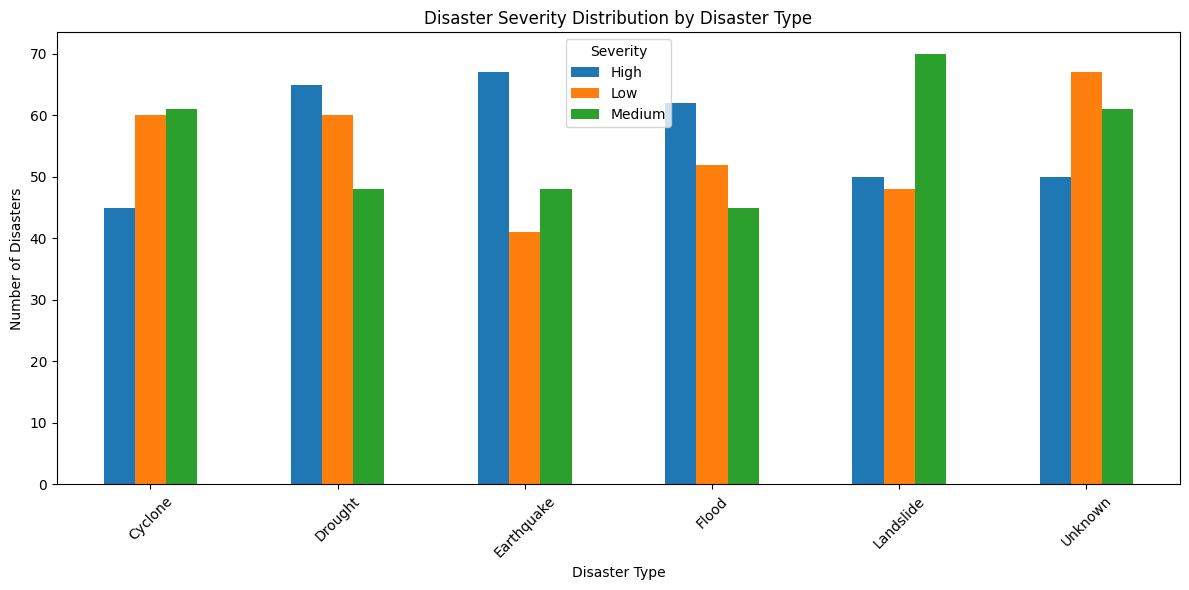

In [52]:
import matplotlib.pyplot as plt

severity_pivot = severity_data.pivot(
    index="disaster_type",
    columns="severity",
    values="disaster_count"
)

severity_pivot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Disaster Severity Distribution by Disaster Type")
plt.xlabel("Disaster Type")
plt.ylabel("Number of Disasters")
plt.xticks(rotation=45)
plt.legend(title="Severity")

plt.tight_layout()
plt.show()

In [53]:
conn = mysql.connector.connect(
    host="localhost",
    user="disaster_user",
    password="disaster123",
    database="disaster_db"
)

query = """
SELECT
    de.disaster_type,
    SUM(ia.economic_loss_musd) AS total_economic_loss_musd
FROM disaster_events de
JOIN impact_assessment ia
    ON de.event_id = ia.event_id
GROUP BY de.disaster_type
ORDER BY total_economic_loss_musd DESC;
"""

economic_loss_data = pd.read_sql(query, conn)

conn.close()

display(economic_loss_data)

/tmp/ipykernel_504/871242448.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  economic_loss_data = pd.read_sql(query, conn)


,disaster_type,total_economic_loss_musd
0,Unknown,217025.78
1,Drought,210797.90
2,Flood,208591.43
3,Landslide,196631.85
4,Earthquake,174252.97
5,Cyclone,153462.02


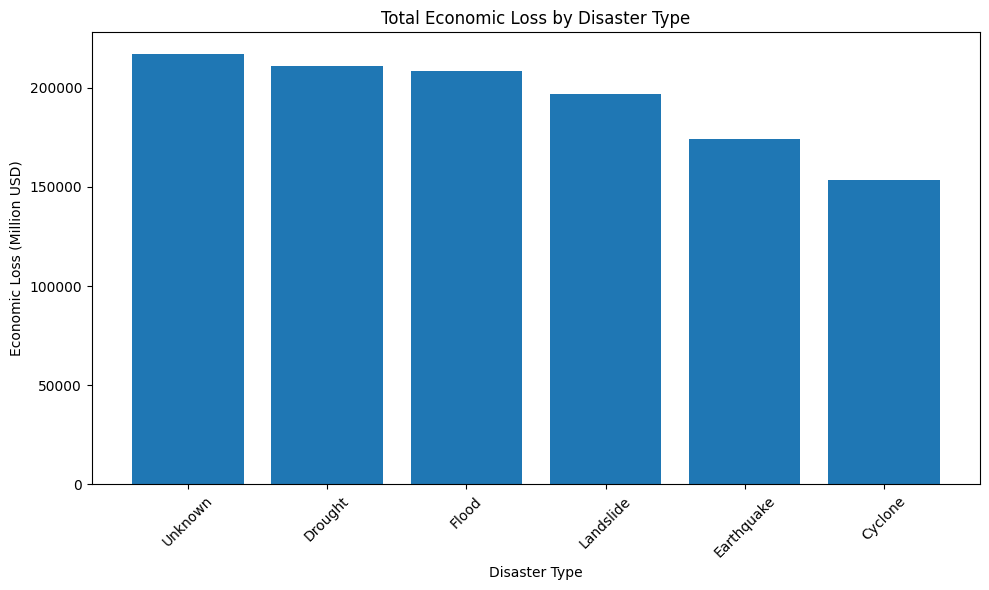

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    economic_loss_data["disaster_type"],
    economic_loss_data["total_economic_loss_musd"]
)

plt.title("Total Economic Loss by Disaster Type")
plt.xlabel("Disaster Type")
plt.ylabel("Economic Loss (Million USD)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [55]:
conn = mysql.connector.connect(
    host="localhost",
    user="disaster_user",
    password="disaster123",
    database="disaster_db"
)

query = """
SELECT
    YEAR(event_date) AS event_year,
    COUNT(*) AS disaster_count
FROM disaster_events
WHERE event_date IS NOT NULL
GROUP BY YEAR(event_date)
ORDER BY event_year;
"""

yearly_disasters = pd.read_sql(query, conn)

conn.close()

display(yearly_disasters)

/tmp/ipykernel_504/1278320036.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  yearly_disasters = pd.read_sql(query, conn)


,event_year,disaster_count
0,2021,294
1,2022,270
2,2023,295
3,2024,98


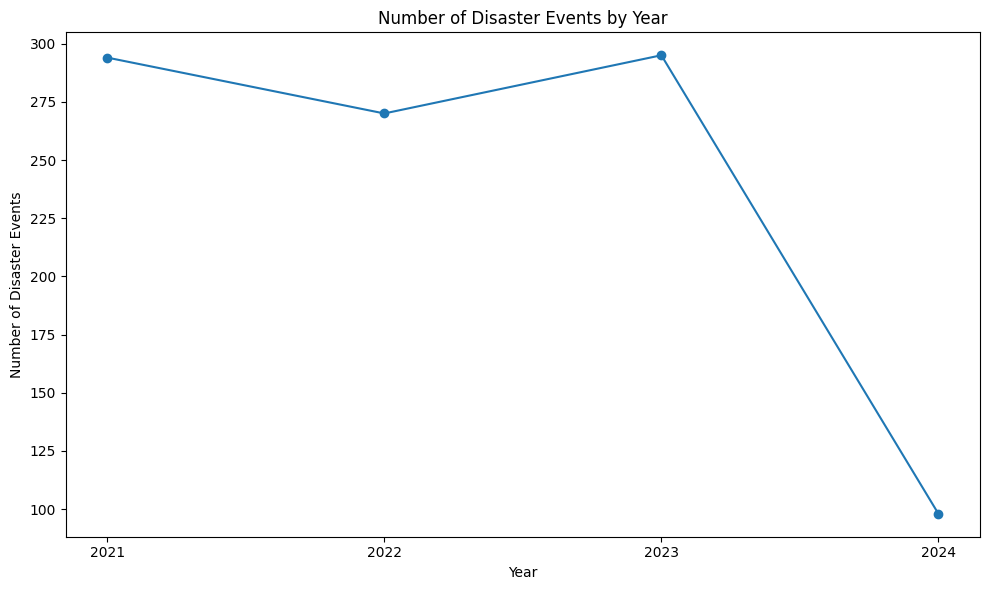

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    yearly_disasters["event_year"],
    yearly_disasters["disaster_count"],
    marker="o"
)

plt.title("Number of Disaster Events by Year")
plt.xlabel("Year")
plt.ylabel("Number of Disaster Events")

plt.xticks(yearly_disasters["event_year"])

plt.tight_layout()
plt.show()

In [57]:
conn = mysql.connector.connect(
    host="localhost",
    user="disaster_user",
    password="disaster123",
    database="disaster_db"
)

query = """
SELECT
    de.region,
    ROUND(AVG(ia.affected_people), 2) AS avg_affected_people
FROM disaster_events de
JOIN impact_assessment ia
    ON de.event_id = ia.event_id
GROUP BY de.region
ORDER BY avg_affected_people DESC;
"""

avg_impact_data = pd.read_sql(query, conn)

conn.close()

display(avg_impact_data)

/tmp/ipykernel_504/3878560007.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  avg_impact_data = pd.read_sql(query, conn)


,region,avg_affected_people
0,West Bengal,1393764.50
1,Bihar,1370662.66
2,Gujarat,1368676.31
3,Odisha,1315735.74
4,Tamil Nadu,1298889.63
5,UP,1289889.55
6,Assam,1179772.63
7,Kerala,1031112.04


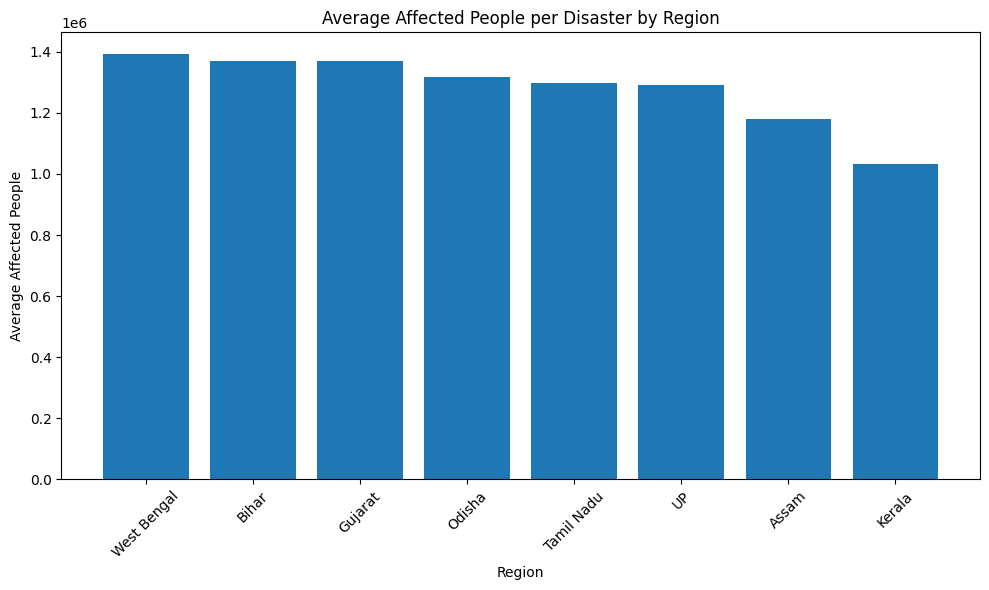

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    avg_impact_data["region"],
    avg_impact_data["avg_affected_people"]
)

plt.title("Average Affected People per Disaster by Region")
plt.xlabel("Region")
plt.ylabel("Average Affected People")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [59]:
conn = mysql.connector.connect(
    host="localhost",
    user="disaster_user",
    password="disaster123",
    database="disaster_db"
)

query = """
SELECT
    region,
    COUNT(*) AS disaster_count
FROM disaster_events
GROUP BY region
ORDER BY disaster_count DESC;
"""

region_disaster_count = pd.read_sql(query, conn)

conn.close()

display(region_disaster_count)

/tmp/ipykernel_504/187026119.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  region_disaster_count = pd.read_sql(query, conn)


,region,disaster_count
0,Tamil Nadu,134
1,Assam,132
2,UP,131
3,West Bengal,129
4,Bihar,129
5,Gujarat,121
6,Kerala,113
7,Odisha,111


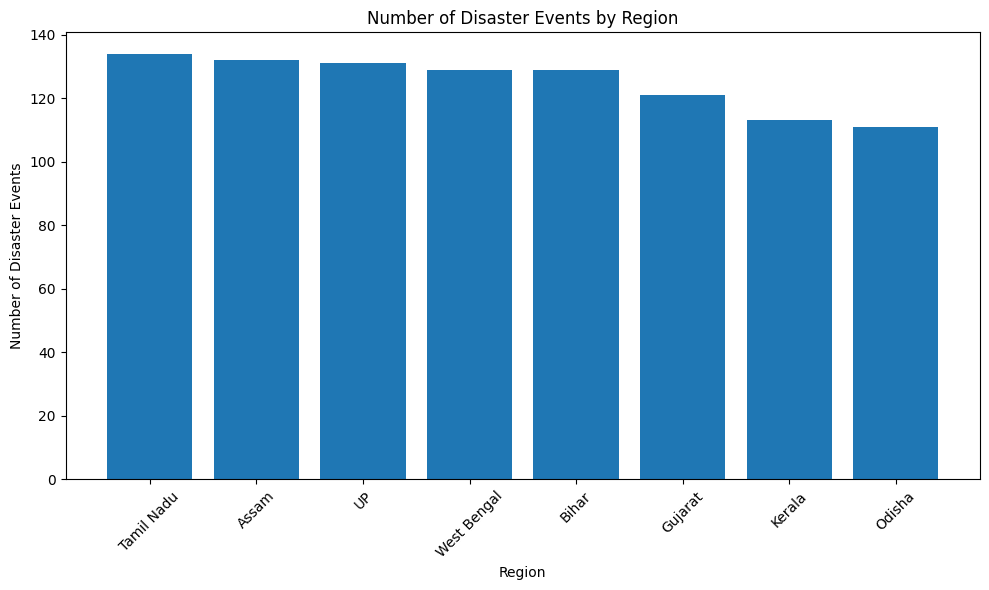

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    region_disaster_count["region"],
    region_disaster_count["disaster_count"]
)

plt.title("Number of Disaster Events by Region")
plt.xlabel("Region")
plt.ylabel("Number of Disaster Events")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [61]:
conn = mysql.connector.connect(
    host="localhost",
    user="disaster_user",
    password="disaster123",
    database="disaster_db"
)

query = """
SELECT
    de.region,
    ROUND(SUM(ia.economic_loss_musd), 2) AS total_economic_loss_musd
FROM disaster_events de
JOIN impact_assessment ia
    ON de.event_id = ia.event_id
GROUP BY de.region
ORDER BY total_economic_loss_musd DESC;
"""

regional_economic_loss = pd.read_sql(query, conn)

conn.close()

display(regional_economic_loss)

/tmp/ipykernel_504/265361577.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  regional_economic_loss = pd.read_sql(query, conn)


,region,total_economic_loss_musd
0,Kerala,194988.41
1,West Bengal,157022.52
2,Bihar,154092.98
3,Assam,147647.18
4,Odisha,134606.08
5,Gujarat,132897.89
6,UP,129418.73
7,Tamil Nadu,110088.16


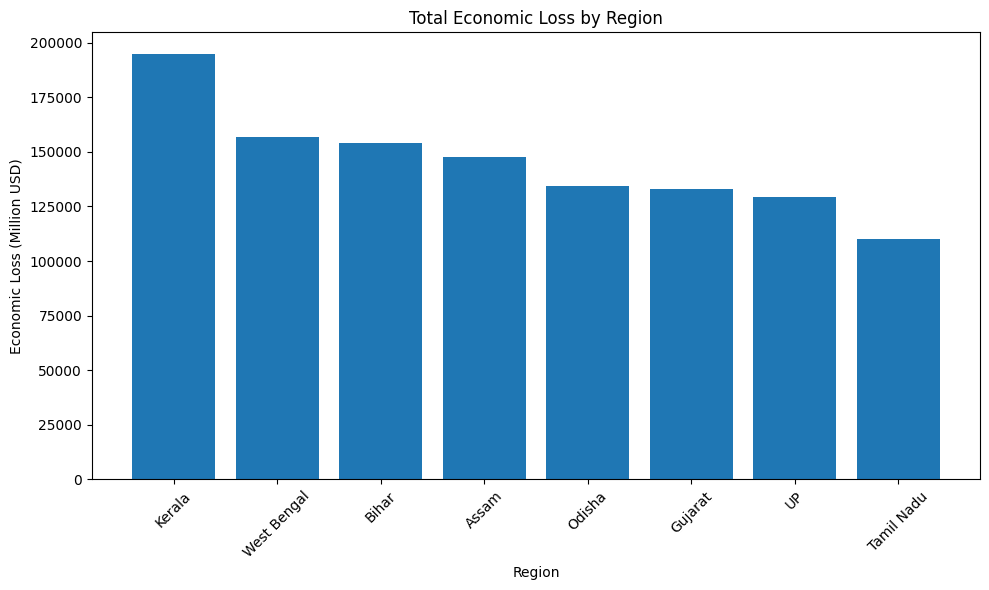

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    regional_economic_loss["region"],
    regional_economic_loss["total_economic_loss_musd"]
)

plt.title("Total Economic Loss by Region")
plt.xlabel("Region")
plt.ylabel("Economic Loss (Million USD)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [63]:
conn = mysql.connector.connect(
    host="localhost",
    user="disaster_user",
    password="disaster123",
    database="disaster_db"
)

query = """
SELECT
    de.severity,
    ROUND(AVG(ia.economic_loss_musd), 2) AS avg_economic_loss_musd
FROM disaster_events de
JOIN impact_assessment ia
    ON de.event_id = ia.event_id
GROUP BY de.severity
ORDER BY avg_economic_loss_musd DESC;
"""

severity_economic_loss = pd.read_sql(query, conn)

conn.close()

display(severity_economic_loss)

/tmp/ipykernel_504/3129783911.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  severity_economic_loss = pd.read_sql(query, conn)


,severity,avg_economic_loss_musd
0,High,1316.30
1,Medium,1108.54
2,Low,1054.21


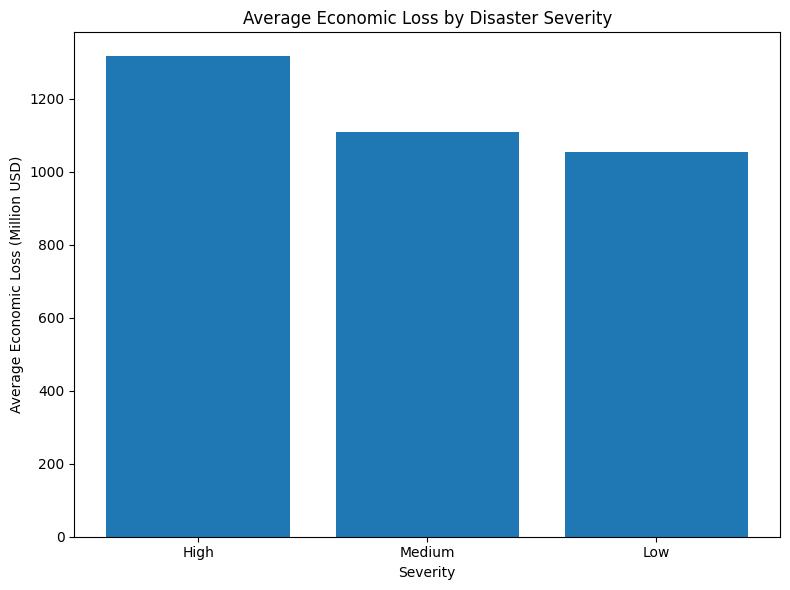

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.bar(
    severity_economic_loss["severity"],
    severity_economic_loss["avg_economic_loss_musd"]
)

plt.title("Average Economic Loss by Disaster Severity")
plt.xlabel("Severity")
plt.ylabel("Average Economic Loss (Million USD)")

plt.tight_layout()
plt.show()

In [65]:
conn = mysql.connector.connect(
    host="localhost",
    user="disaster_user",
    password="disaster123",
    database="disaster_db"
)

query = """
SELECT
    de.disaster_type,
    SUM(ia.affected_people) AS total_affected_people
FROM disaster_events de
JOIN impact_assessment ia
    ON de.event_id = ia.event_id
GROUP BY de.disaster_type
ORDER BY total_affected_people DESC;
"""

disaster_type_impact = pd.read_sql(query, conn)

conn.close()

display(disaster_type_impact)

/tmp/ipykernel_504/3947990225.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  disaster_type_impact = pd.read_sql(query, conn)


,disaster_type,total_affected_people
0,Flood,227465889.0
1,Cyclone,227237344.0
2,Earthquake,210615943.0
3,Unknown,207545349.0
4,Drought,202567533.0
5,Landslide,201055927.0


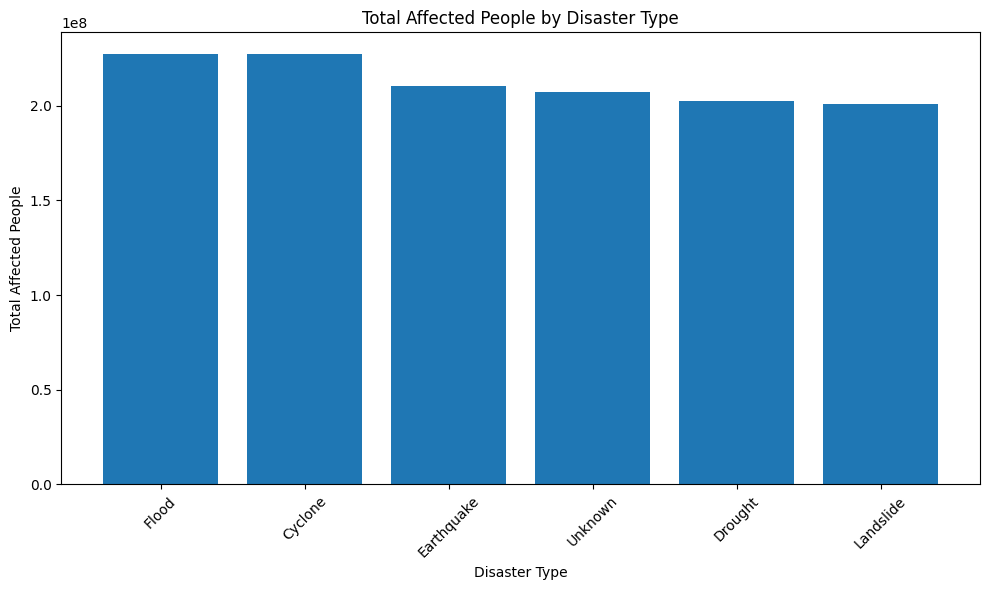

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    disaster_type_impact["disaster_type"],
    disaster_type_impact["total_affected_people"]
)

plt.title("Total Affected People by Disaster Type")
plt.xlabel("Disaster Type")
plt.ylabel("Total Affected People")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [67]:
conn = mysql.connector.connect(
    host="localhost",
    user="disaster_user",
    password="disaster123",
    database="disaster_db"
)

query = """
SELECT
    de.event_id,
    de.disaster_type,
    de.region,
    de.severity,
    ia.affected_people
FROM disaster_events de
JOIN impact_assessment ia
    ON de.event_id = ia.event_id
ORDER BY ia.affected_people DESC
LIMIT 5;
"""

top5_events = pd.read_sql(query, conn)

conn.close()

display(top5_events)

/tmp/ipykernel_504/226719425.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  top5_events = pd.read_sql(query, conn)


,event_id,disaster_type,region,severity,affected_people
0,342,Unknown,Assam,High,4986682
1,489,Cyclone,UP,Medium,4983209
2,489,Cyclone,UP,Medium,4969657
3,349,Flood,Tamil Nadu,High,4968737
4,194,Earthquake,Kerala,High,4960313


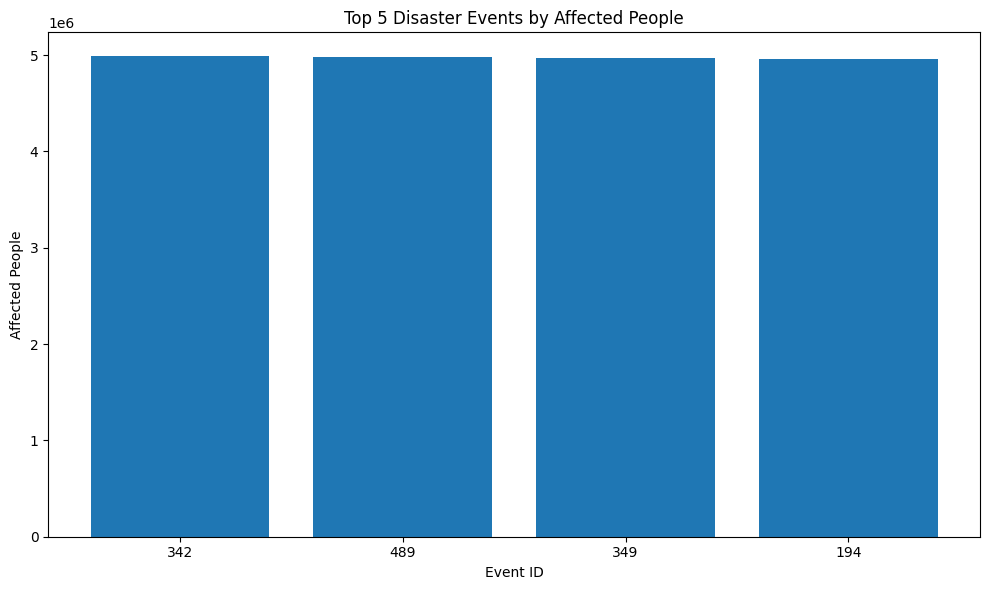

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

event_labels = top5_events["event_id"].astype(str)

plt.bar(
    event_labels,
    top5_events["affected_people"]
)

plt.title("Top 5 Disaster Events by Affected People")
plt.xlabel("Event ID")
plt.ylabel("Affected People")

plt.tight_layout()
plt.show()

In [69]:
print(final_data.shape)

(1354, 10)


In [70]:
final_data.to_csv(
    "/content/final_disaster_data.csv",
    index=False
)

print("Final dataset saved successfully!")

Final dataset saved successfully!
